In [1]:
import sys
from pathlib import Path

ROOT = str(Path.cwd().parent)
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from src.data_loader import load_all_datasets
from src.preprocessing import add_rul_column, add_binary_label
from src.config import DATASETS, USEFUL_SENSORS, MAX_RUL, CLASSIFICATION_W

sns.set_theme(style="whitegrid")
data = load_all_datasets()

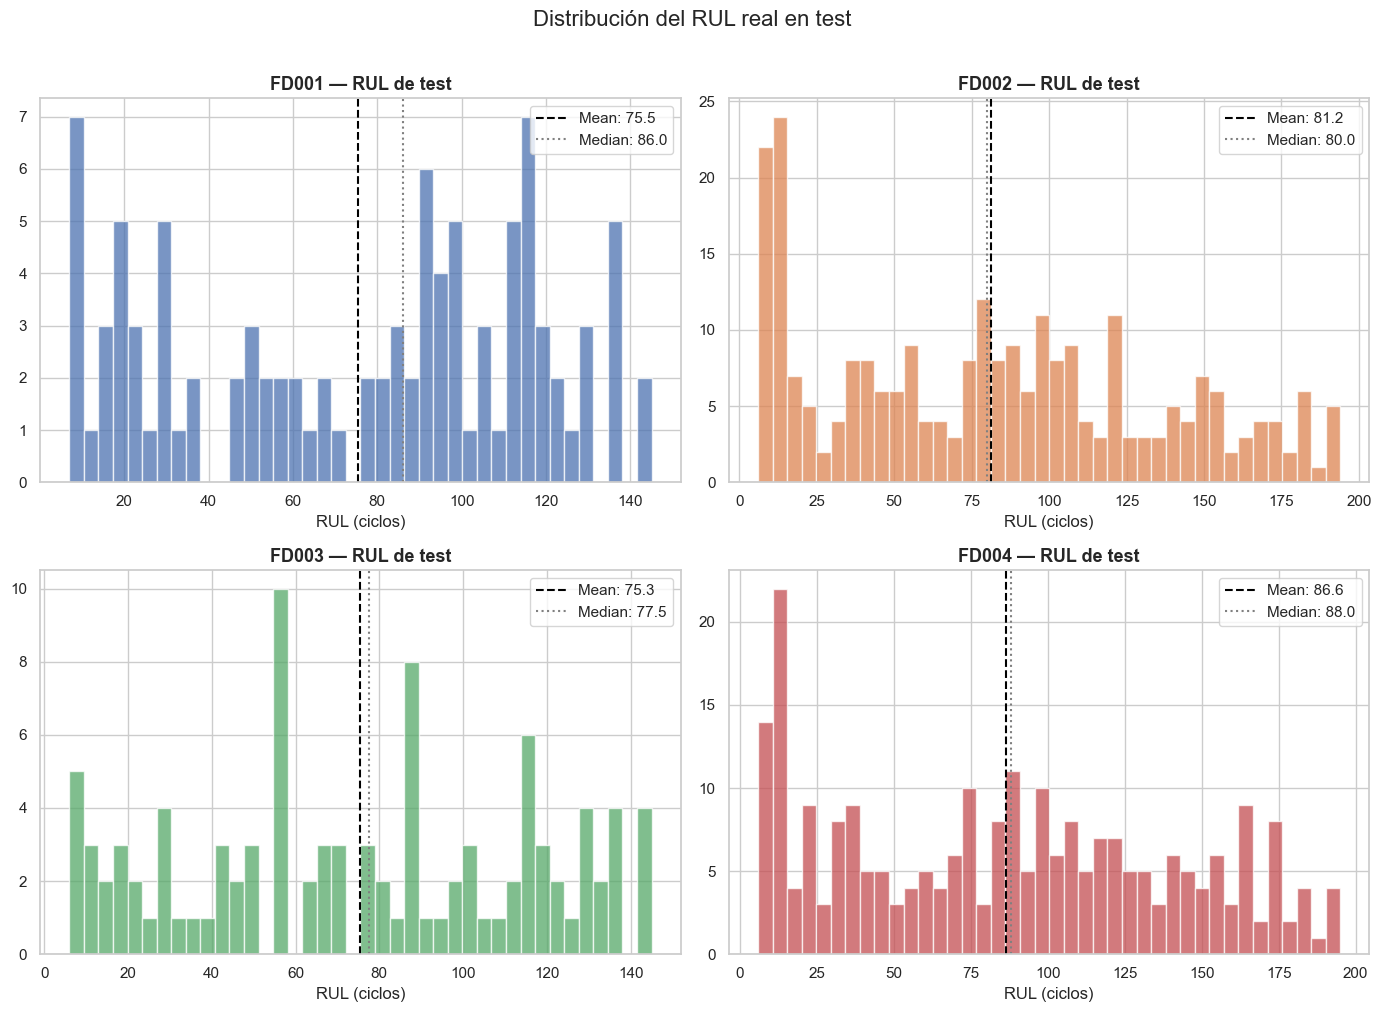

In [2]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

for i, ds_id in enumerate(DATASETS):
    rul = data[ds_id][2]
    axes[i].hist(rul, bins=40, color=colors[i], alpha=0.75, edgecolor="white")
    axes[i].axvline(rul.mean(), color="black", linestyle="--", linewidth=1.5, label=f"Mean: {rul.mean():.1f}")
    axes[i].axvline(rul.median(), color="gray", linestyle=":", linewidth=1.5, label=f"Median: {rul.median():.1f}")
    axes[i].set_title(f"{ds_id} — RUL de test", fontsize=13, fontweight="bold")
    axes[i].set_xlabel("RUL (ciclos)")
    axes[i].legend()

plt.suptitle("Distribución del RUL real en test", fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

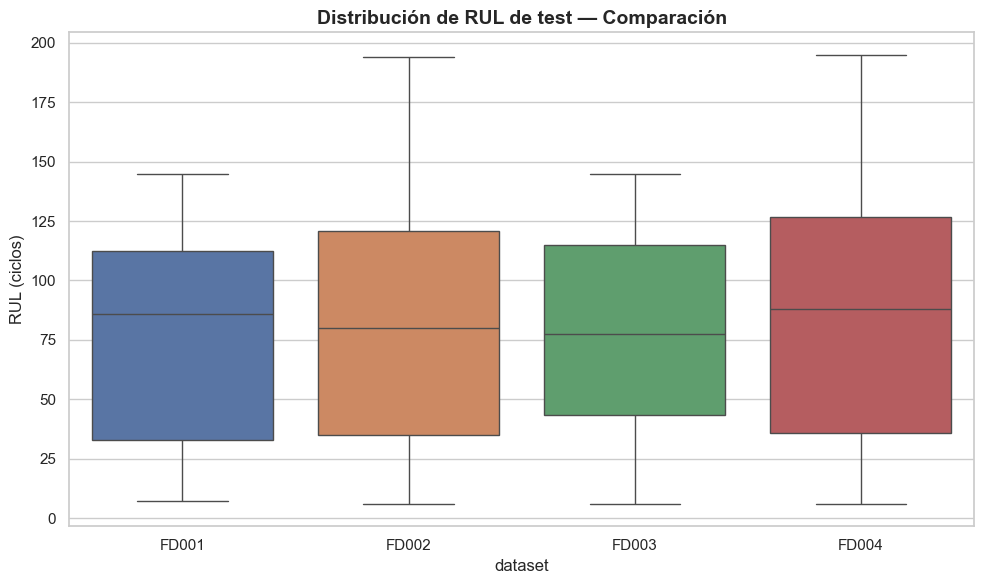

In [3]:
rul_frames = []
for ds_id in DATASETS:
    rul = data[ds_id][2]
    rul_frames.append(pd.DataFrame({"rul": rul, "dataset": ds_id}))

rul_all = pd.concat(rul_frames, ignore_index=True)

fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=rul_all, x="dataset", y="rul", hue="dataset", palette=colors, legend=False, ax=ax)
ax.set_ylabel("RUL (ciclos)")
ax.set_title("Distribución de RUL de test — Comparación", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

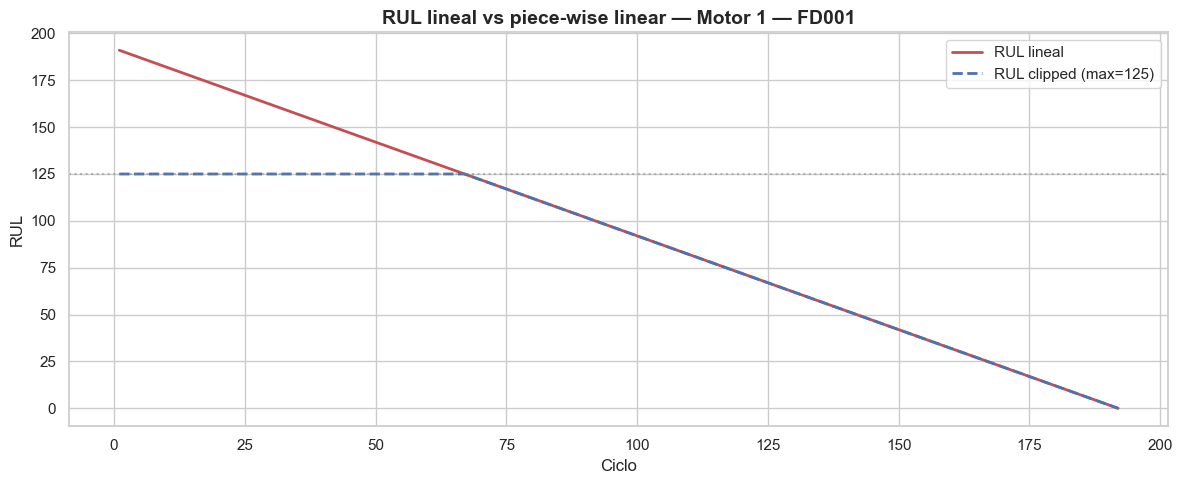

In [4]:
train = data["FD001"][0].copy()
max_cycles = train.groupby("unit_id")["cycle"].transform("max")
train["rul_linear"] = max_cycles - train["cycle"]
train["rul_clipped"] = train["rul_linear"].clip(upper=MAX_RUL)

unit = 1
unit_data = train[train["unit_id"] == unit]

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(unit_data["cycle"], unit_data["rul_linear"], color="#C44E52", linewidth=2, label="RUL lineal")
ax.plot(unit_data["cycle"], unit_data["rul_clipped"], color="#4C72B0", linewidth=2, linestyle="--", label=f"RUL clipped (max={MAX_RUL})")
ax.axhline(MAX_RUL, color="gray", linestyle=":", alpha=0.5)
ax.set_xlabel("Ciclo")
ax.set_ylabel("RUL")
ax.set_title(f"RUL lineal vs piece-wise linear — Motor {unit} — FD001", fontsize=14, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

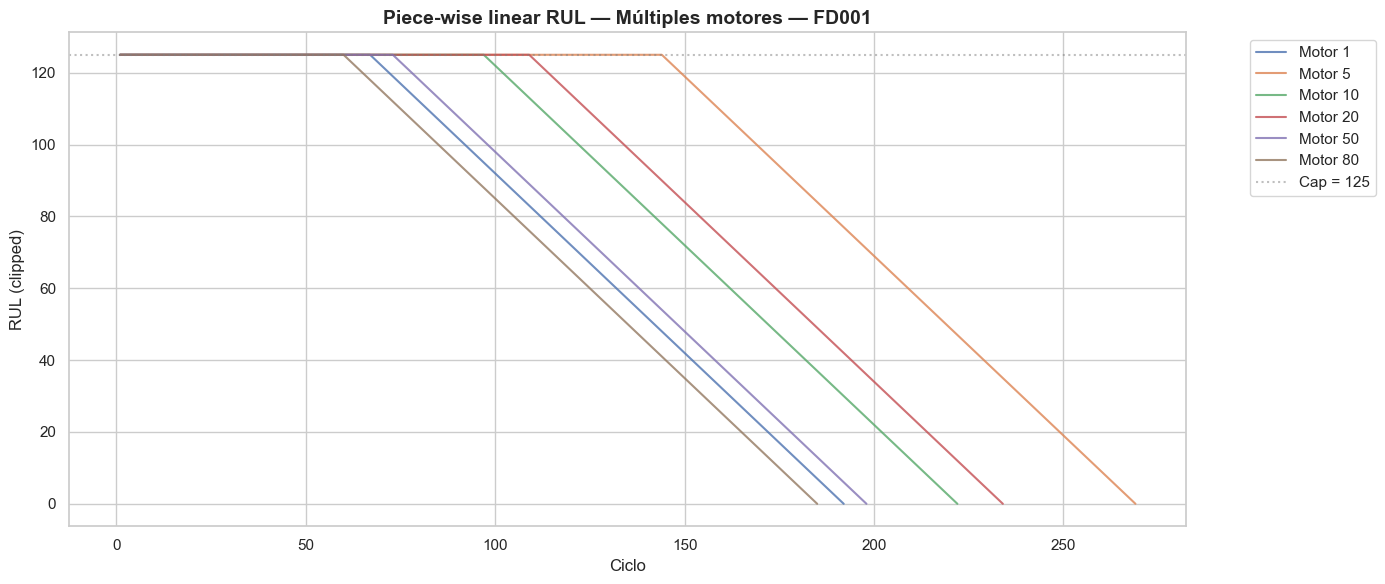

In [5]:
train_rul = add_rul_column(data["FD001"][0])
units = [1, 5, 10, 20, 50, 80]

fig, ax = plt.subplots(figsize=(14, 6))
for unit in units:
    unit_data = train_rul[train_rul["unit_id"] == unit]
    ax.plot(unit_data["cycle"], unit_data["rul"], linewidth=1.5, alpha=0.8, label=f"Motor {unit}")

ax.axhline(MAX_RUL, color="gray", linestyle=":", alpha=0.5, label=f"Cap = {MAX_RUL}")
ax.set_xlabel("Ciclo")
ax.set_ylabel("RUL (clipped)")
ax.set_title("Piece-wise linear RUL — Múltiples motores — FD001", fontsize=14, fontweight="bold")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

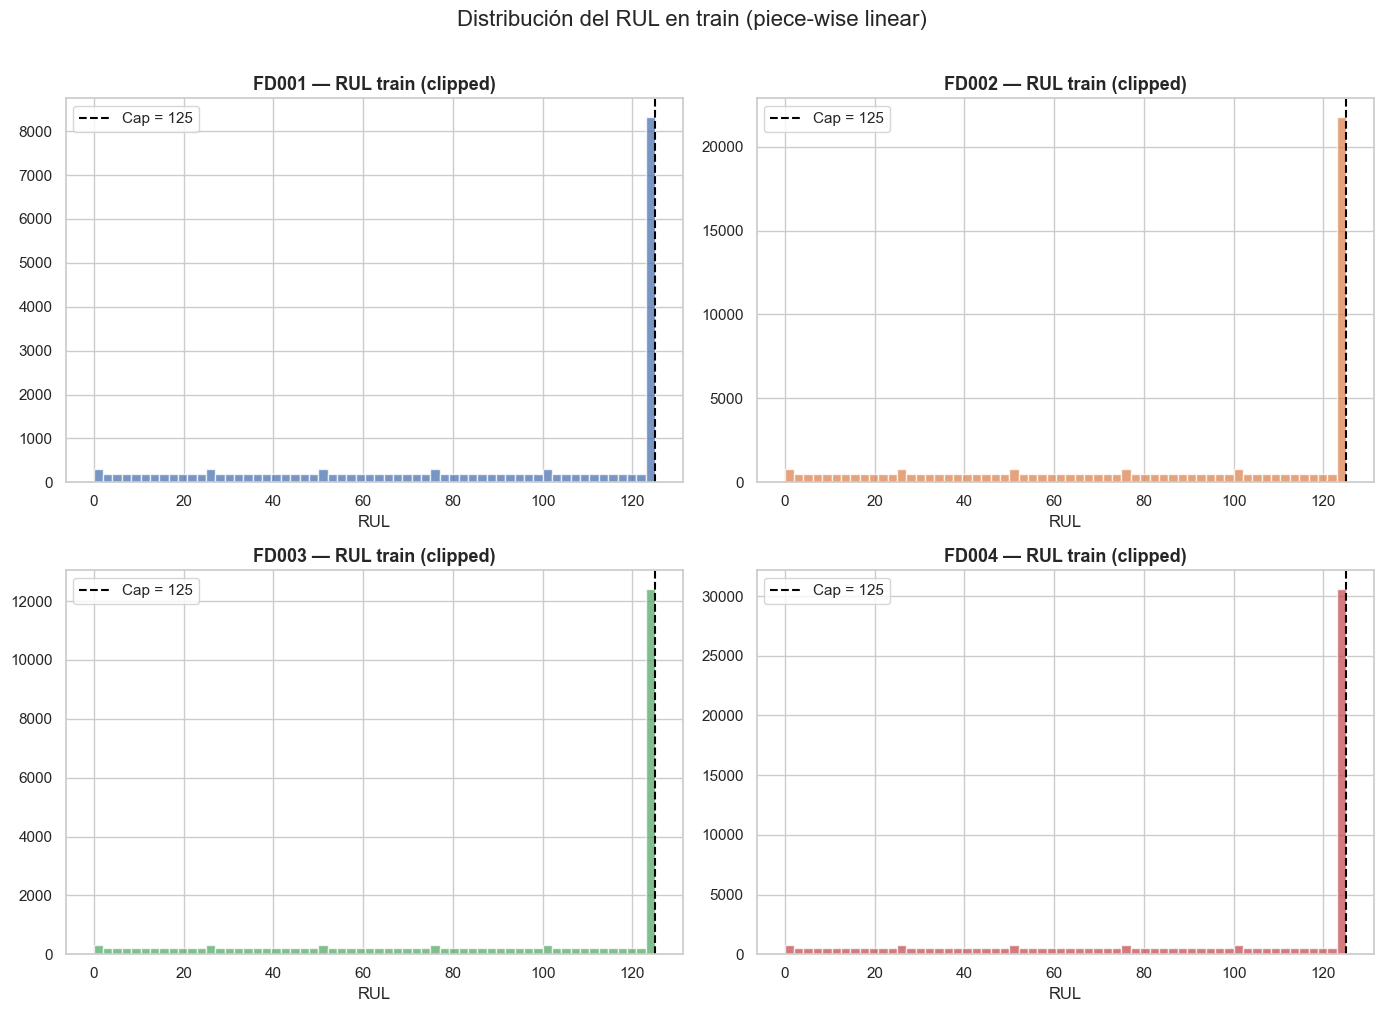

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, ds_id in enumerate(DATASETS):
    tr = add_rul_column(data[ds_id][0])
    axes[i].hist(tr["rul"], bins=60, color=colors[i], alpha=0.75, edgecolor="white")
    axes[i].axvline(MAX_RUL, color="black", linestyle="--", linewidth=1.5, label=f"Cap = {MAX_RUL}")
    axes[i].set_title(f"{ds_id} — RUL train (clipped)", fontsize=13, fontweight="bold")
    axes[i].set_xlabel("RUL")
    axes[i].legend()

plt.suptitle("Distribución del RUL en train (piece-wise linear)", fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

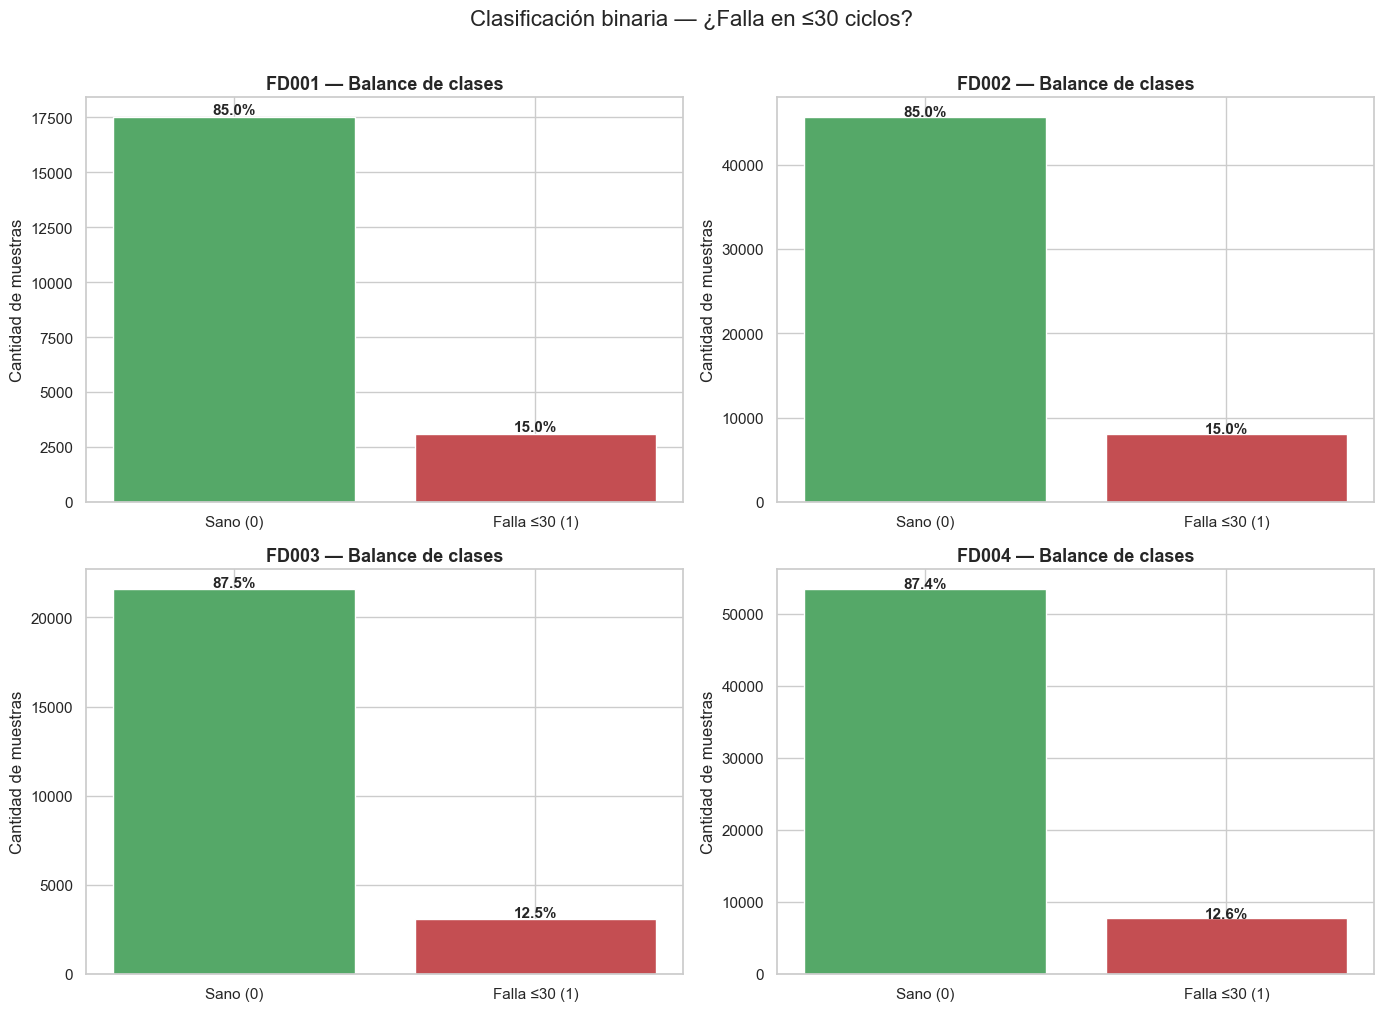

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, ds_id in enumerate(DATASETS):
    tr = add_rul_column(data[ds_id][0])
    tr = add_binary_label(tr)
    counts = tr["label"].value_counts().sort_index()
    pct = counts / counts.sum() * 100
    bars = axes[i].bar(["Sano (0)", f"Falla ≤{CLASSIFICATION_W} (1)"], counts.values, color=["#55A868", "#C44E52"], edgecolor="white")
    for bar, p in zip(bars, pct.values):
        axes[i].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 100, f"{p:.1f}%", ha="center", fontsize=11, fontweight="bold")
    axes[i].set_title(f"{ds_id} — Balance de clases", fontsize=13, fontweight="bold")
    axes[i].set_ylabel("Cantidad de muestras")

plt.suptitle(f"Clasificación binaria — ¿Falla en ≤{CLASSIFICATION_W} ciclos?", fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

In [8]:
ratios = {}
for ds_id in DATASETS:
    tr = add_rul_column(data[ds_id][0])
    tr = add_binary_label(tr)
    counts = tr["label"].value_counts()
    ratios[ds_id] = {
        "sano": counts[0],
        "falla": counts[1],
        "ratio_sano_falla": counts[0] / counts[1],
        "pct_falla": counts[1] / len(tr) * 100,
    }

ratio_df = pd.DataFrame(ratios).T
ratio_df.style.format({"sano": "{:,.0f}", "falla": "{:,.0f}", "ratio_sano_falla": "{:.2f}", "pct_falla": "{:.1f}%"}).background_gradient(cmap="OrRd", subset=["ratio_sano_falla"])

,sano,falla,ratio_sano_falla,pct_falla
FD001,"17,531","3,100",5.66,15.0%
FD002,"45,699","8,060",5.67,15.0%
FD003,"21,620","3,100",6.97,12.5%
FD004,"53,530","7,719",6.93,12.6%


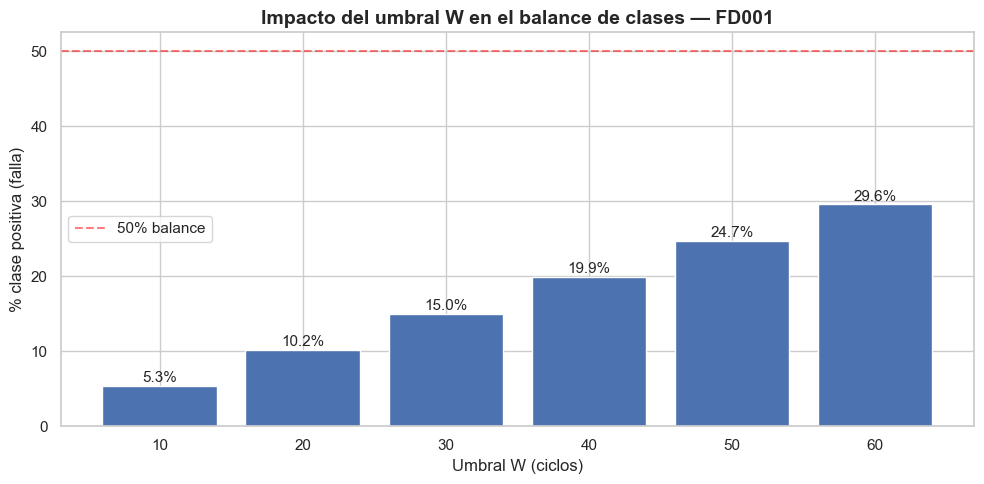

In [9]:
w_values = [10, 20, 30, 40, 50, 60]
train_fd001 = add_rul_column(data["FD001"][0])

pct_falla = []
for w in w_values:
    label = (train_fd001["rul"] <= w).astype(int)
    pct_falla.append(label.mean() * 100)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar([str(w) for w in w_values], pct_falla, color="#4C72B0", edgecolor="white")
for bar, p in zip(bars, pct_falla):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5, f"{p:.1f}%", ha="center", fontsize=11)
ax.axhline(50, color="red", linestyle="--", alpha=0.5, label="50% balance")
ax.set_xlabel("Umbral W (ciclos)")
ax.set_ylabel("% clase positiva (falla)")
ax.set_title("Impacto del umbral W en el balance de clases — FD001", fontsize=14, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

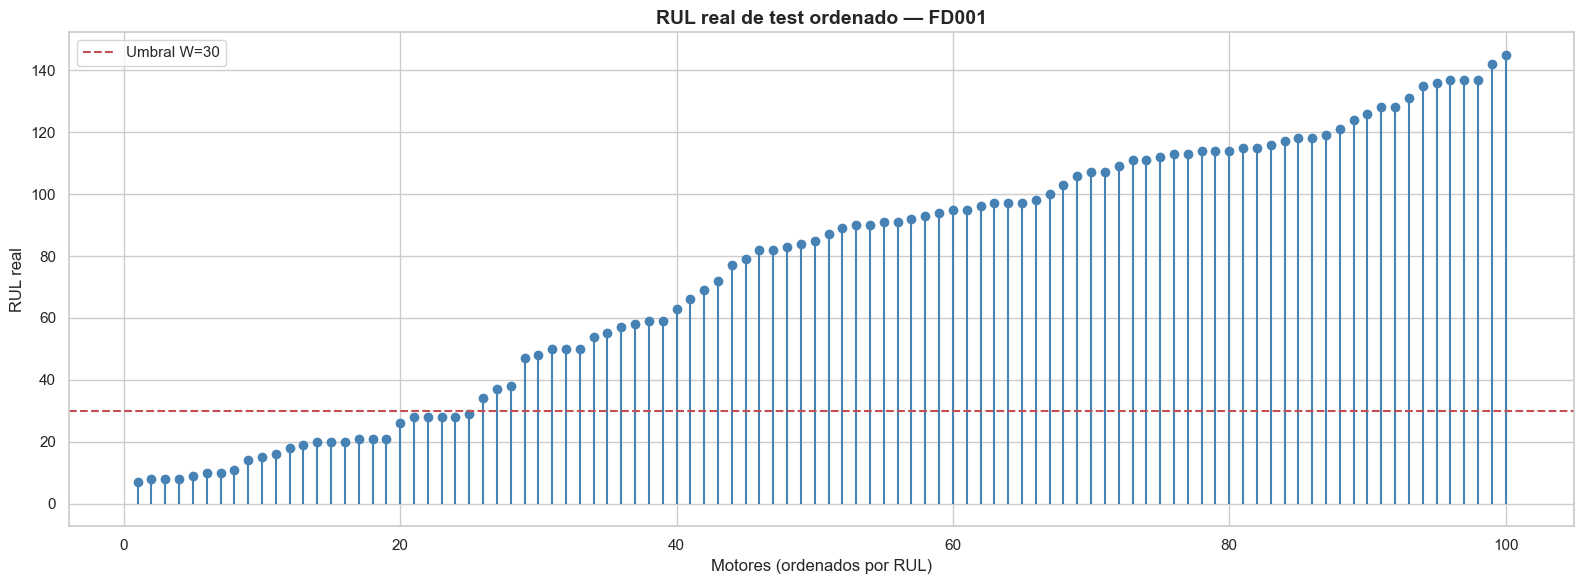

In [10]:
rul_fd001 = data["FD001"][2].reset_index()
rul_fd001.columns = ["motor", "rul"]
rul_fd001 = rul_fd001.sort_values("rul").reset_index(drop=True)
rul_fd001["motor"] = range(1, len(rul_fd001) + 1)

fig, ax = plt.subplots(figsize=(16, 6))
ax.stem(rul_fd001["motor"], rul_fd001["rul"], linefmt="steelblue", markerfmt="o", basefmt=" ")
ax.axhline(CLASSIFICATION_W, color="#C44E52", linestyle="--", linewidth=1.5, label=f"Umbral W={CLASSIFICATION_W}")
ax.set_xlabel("Motores (ordenados por RUL)")
ax.set_ylabel("RUL real")
ax.set_title("RUL real de test ordenado — FD001", fontsize=14, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

In [11]:
fig = go.Figure()

for ds_id, color in zip(DATASETS, ["#636EFA", "#EF553B", "#00CC96", "#AB63FA"]):
    rul = data[ds_id][2].sort_values().values
    fig.add_trace(go.Scatter(
        x=list(range(1, len(rul) + 1)),
        y=rul,
        mode="lines+markers",
        name=ds_id,
        marker=dict(size=4),
        line=dict(width=1.5),
        opacity=0.8,
    ))

fig.add_hline(y=CLASSIFICATION_W, line_dash="dash", line_color="red", annotation_text=f"W={CLASSIFICATION_W}")
fig.update_layout(
    title="RUL real de test — 4 sub-datasets",
    xaxis_title="Motores (ordenados)",
    yaxis_title="RUL",
    template="plotly_white",
    height=550,
    hovermode="x unified",
)
fig.show()

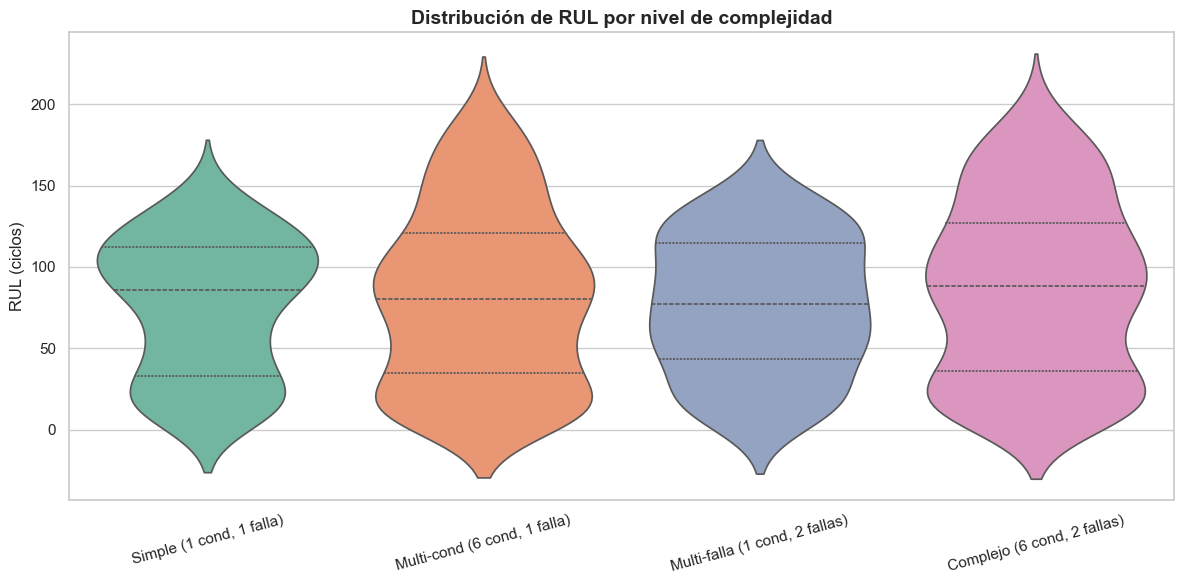

In [12]:
rul_all["complexity"] = rul_all["dataset"].map({
    "FD001": "Simple (1 cond, 1 falla)",
    "FD002": "Multi-cond (6 cond, 1 falla)",
    "FD003": "Multi-falla (1 cond, 2 fallas)",
    "FD004": "Complejo (6 cond, 2 fallas)",
})

fig, ax = plt.subplots(figsize=(12, 6))
sns.violinplot(data=rul_all, x="complexity", y="rul", hue="complexity", palette="Set2", inner="quartile", legend=False, ax=ax)
ax.set_xlabel("")
ax.set_ylabel("RUL (ciclos)")
ax.set_title("Distribución de RUL por nivel de complejidad", fontsize=14, fontweight="bold")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

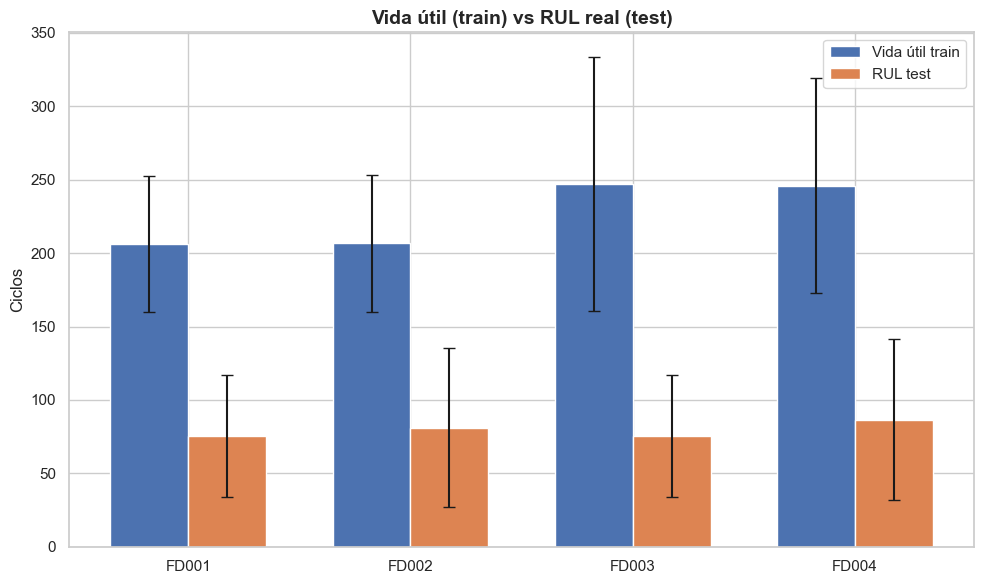

In [13]:
comparison = {}
for ds_id in DATASETS:
    train_ds = data[ds_id][0]
    rul = data[ds_id][2]
    max_cycles = train_ds.groupby("unit_id")["cycle"].max()
    comparison[ds_id] = {
        "vida_util_train_mean": max_cycles.mean(),
        "vida_util_train_std": max_cycles.std(),
        "rul_test_mean": rul.mean(),
        "rul_test_std": rul.std(),
    }

comp_df = pd.DataFrame(comparison).T

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(DATASETS))
w = 0.35
ax.bar(x - w / 2, comp_df["vida_util_train_mean"], w, yerr=comp_df["vida_util_train_std"], label="Vida útil train", color="#4C72B0", edgecolor="white", capsize=4)
ax.bar(x + w / 2, comp_df["rul_test_mean"], w, yerr=comp_df["rul_test_std"], label="RUL test", color="#DD8452", edgecolor="white", capsize=4)
ax.set_xticks(x)
ax.set_xticklabels(DATASETS)
ax.set_ylabel("Ciclos")
ax.set_title("Vida útil (train) vs RUL real (test)", fontsize=14, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

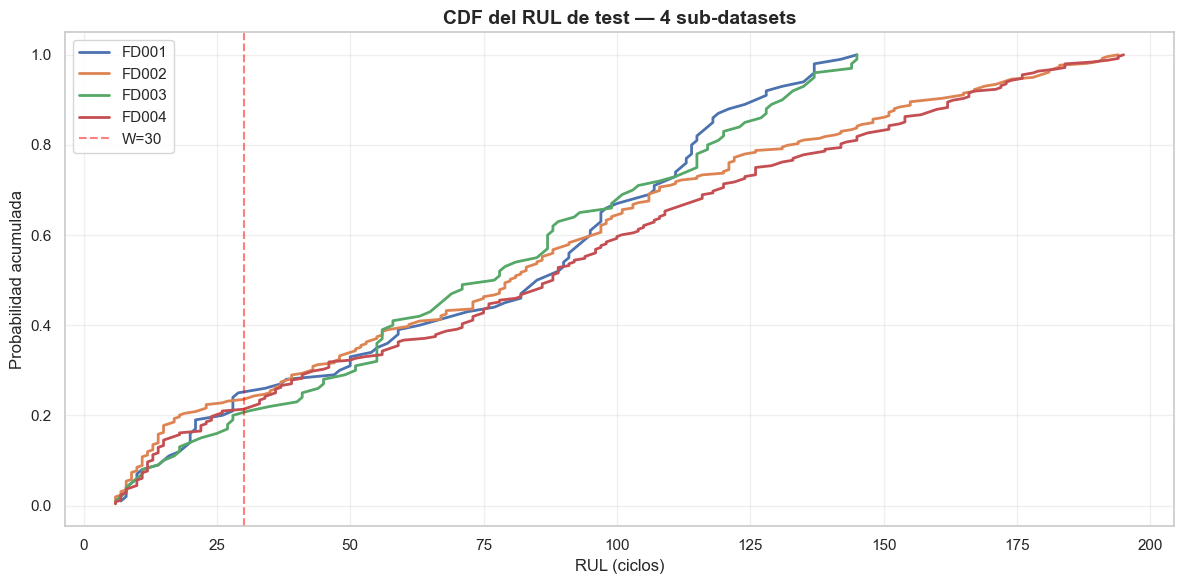

In [14]:
fig, ax = plt.subplots(figsize=(12, 6))

for ds_id, color in zip(DATASETS, colors):
    rul = np.sort(data[ds_id][2].values)
    cdf = np.arange(1, len(rul) + 1) / len(rul)
    ax.plot(rul, cdf, linewidth=2, label=ds_id, color=color)

ax.axvline(CLASSIFICATION_W, color="red", linestyle="--", alpha=0.5, label=f"W={CLASSIFICATION_W}")
ax.set_xlabel("RUL (ciclos)")
ax.set_ylabel("Probabilidad acumulada")
ax.set_title("CDF del RUL de test — 4 sub-datasets", fontsize=14, fontweight="bold")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [15]:
print("=" * 60)
print("  RESUMEN ANÁLISIS RUL")
print("=" * 60)
for ds_id in DATASETS:
    rul = data[ds_id][2]
    tr = add_rul_column(data[ds_id][0])
    tr = add_binary_label(tr)
    pct = tr["label"].mean() * 100
    print(f"  {ds_id}: RUL test mean={rul.mean():.1f} | median={rul.median():.1f} | clase falla={pct:.1f}%")
print(f"\n  Umbral clasificación W = {CLASSIFICATION_W}")
print(f"  Cap RUL (piece-wise) = {MAX_RUL}")
print(f"  FD004 tiene la distribución más dispersa")
print(f"  Desbalance de clases presente en todos los sub-datasets")
print("=" * 60)

  RESUMEN ANÁLISIS RUL
  FD001: RUL test mean=75.5 | median=86.0 | clase falla=15.0%
  FD002: RUL test mean=81.2 | median=80.0 | clase falla=15.0%
  FD003: RUL test mean=75.3 | median=77.5 | clase falla=12.5%
  FD004: RUL test mean=86.6 | median=88.0 | clase falla=12.6%

  Umbral clasificación W = 30
  Cap RUL (piece-wise) = 125
  FD004 tiene la distribución más dispersa
  Desbalance de clases presente en todos los sub-datasets
